In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)

In [3]:
TRAINING_DATA_PATH = Path("data/processed/combined_df_20hz.csv")
df = pd.read_csv(TRAINING_DATA_PATH)
df.head()

,id,ph_acc_x,ph_acc_y,ph_acc_z,ph_gyro_x,ph_gyro_y,ph_gyro_z,wh_acc_x,wh_acc_y,wh_acc_z,wh_gyro_x,wh_gyro_y,wh_gyro_z,activity
0,1600,-0.101778,1.557808,0.089097,-1.090658,0.352269,1.438296,0.943202,0.732314,1.221877,0.232923,-0.705485,-0.237265,A
1,1600,-0.191504,1.701094,0.081574,-1.118625,0.026452,0.272075,0.635555,0.817363,0.923344,0.280032,-0.415893,-0.048394,A
2,1600,0.306371,1.897631,0.395758,-0.922546,0.452499,-0.445995,0.389262,0.810994,0.807265,0.066276,-0.121705,-0.153698,A
3,1600,0.046958,2.123847,-0.073955,-0.732984,1.415060,-0.389128,0.329807,0.812427,0.796575,0.044993,0.211394,-0.122077,A
4,1600,-0.404775,2.312251,-0.974909,-0.490322,1.407640,-0.342950,0.470396,0.651979,1.145822,0.063254,0.541511,-0.016413,A


In [4]:
df.groupby(["id", "activity"]).size().reset_index(name="count")

,id,activity,count
0,1600,A,3594
1,1600,B,3594
2,1600,C,3594
3,1600,D,3595
4,1600,E,3594
...,...,...,...
896,1650,O,3595
897,1650,P,3595
898,1650,Q,3595
899,1650,R,3595


# Windowing

Cut every (subject, activity) recording into fixed-length windows.
The table is already resampled to 20 Hz and z-scored, so a window of 250 rows is 12.5 seconds and a stride of 50 rows is 2.5 seconds.

In [5]:
WINDOW_SIZE = 250  # rows per window: 12.5 s at 20 Hz
STRIDE = 50  # rows between two window starts: 2.5 s, so windows overlap

ACTIVITY_MAP = {
    "A": "walking",
    "B": "jogging",
    "C": "stairs",
    "D": "sitting",
    "E": "standing",
    "F": "typing",
    "G": "teeth",
    "H": "soup",
    "I": "chips",
    "J": "pasta",
    "K": "drinking",
    "L": "sandwich",
    "M": "kicking",
    "O": "catch",
    "P": "dribbling",
    "Q": "writing",
    "R": "clapping",
    "S": "folding",
}
FEATURE_COLS = [col for col in df.columns if col not in ("id", "activity")]

print(f"{len(FEATURE_COLS)} channels:", FEATURE_COLS)

12 channels: ['ph_acc_x', 'ph_acc_y', 'ph_acc_z', 'ph_gyro_x', 'ph_gyro_y', 'ph_gyro_z', 'wh_acc_x', 'wh_acc_y', 'wh_acc_z', 'wh_gyro_x', 'wh_gyro_y', 'wh_gyro_z']


Find where each trial starts and ends. The rows of one trial sit next to each other in the file,
so a trial is described by its first row number and its length.

In [6]:
trials = (
    df.groupby(["id", "activity"], sort=False, observed=True)
    .size()
    .rename("rows")
    .reset_index()
)
trials["start_row"] = (
    trials["rows"].cumsum() - trials["rows"]
)  # first row of the trial in df
trials["n_windows"] = ((trials["rows"] - WINDOW_SIZE) // STRIDE + 1).clip(lower=0)

print(f"{len(trials)} trials, {trials['n_windows'].sum():,} windows")
trials.head()

901 trials, 60,373 windows


,id,activity,rows,start_row,n_windows
0,1600,A,3594,0,67
1,1600,B,3594,3594,67
2,1600,C,3594,7188,67
3,1600,D,3595,10782,67
4,1600,E,3594,14377,67


Make one row per window, holding the window's first row number in `df`, its activity and its subject.
`repeat` copies each trial's details once per window, and `start_row + STRIDE * position` gives each window's start.

In [7]:
windows = trials.loc[trials.index.repeat(trials["n_windows"])].reset_index(drop=True)
windows["position"] = windows.groupby(
    ["id", "activity"], sort=False, observed=True
).cumcount()
windows["window_start"] = windows["start_row"] + STRIDE * windows["position"]
windows = windows[["id", "activity", "window_start"]]

print(f"{len(windows):,} windows")
windows.head()

60,373 windows


,id,activity,window_start
0,1600,A,0
1,1600,A,50
2,1600,A,100
3,1600,A,150
4,1600,A,200


# From pandas to numpy

Everything above is bookkeeping in pandas. This is the one place the data becomes arrays for PyTorch:
`X` holds the signals, `y` the activity number and `groups` the subject of each window.

In [8]:
features = df[FEATURE_COLS].to_numpy(dtype=np.float32)  # (rows, 12)
print("Features:", features.shape)
offsets = np.arange(WINDOW_SIZE)  # 0..249, added to each window start

X = features[
    windows["window_start"].to_numpy()[:, None] + offsets
]  # (n_windows, 250, 12)

activity_codes = windows["activity"].astype("category")
classes = list(activity_codes.cat.categories)
class_names = [ACTIVITY_MAP[c] for c in classes]
y = activity_codes.cat.codes.to_numpy(dtype=np.int64)
groups = windows["id"].to_numpy(dtype=np.int64)

del features
print("X:", X.shape, X.dtype, f"{X.nbytes / 1e9:.2f} GB")
print("y:", y.shape, " groups:", groups.shape, " classes:", len(classes))

Features: (3239078, 12)
X: (60373, 250, 12) float32 0.72 GB
y: (60373,)  groups: (60373,)  classes: 18


# Train / validation split

Split by subject: about 80% of the subjects for training and 20% for validation, with no subject in both.
The channels are already z-scored in the CSV, so no scaling is needed here.

In [8]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(splitter.split(X, y, groups))

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
del X

print("train windows:", len(y_train), " val windows:", len(y_val))
print(
    "train subjects:",
    len(set(groups[train_idx])),
    " val subjects:",
    len(set(groups[val_idx])),
)

train windows: 47307  val windows: 13066
train subjects: 40  val subjects: 11


Pick where to run (Apple GPU `mps`, NVIDIA `cuda`, or CPU) and compute class weights, so every activity counts equally in the loss.

In [9]:
num_classes = len(classes)

torch_device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available() else "cpu"
)
print("Using device:", torch_device)

class_counts = np.bincount(y_train, minlength=num_classes)
class_weights = torch.tensor(
    class_counts.sum() / (num_classes * np.maximum(class_counts, 1)),
    dtype=torch.float32,
    device=torch_device,
)

print("counts per class:", class_counts)
print("class weights:   ", class_weights.cpu().numpy().round(3))

Using device: mps
counts per class: [2681 2546 2546 2680 2680 2546 2680 2613 2680 2546 2680 2546 2682 2546
 2681 2613 2681 2680]
class weights:    [0.98  1.032 1.032 0.981 0.981 1.032 0.981 1.006 0.981 1.032 0.981 1.032
 0.98  1.032 0.98  1.006 0.98  0.981]


# CNN

The phone channels (0–5) and the watch channels (6–11) each go through their own 3 convolution blocks.
Each block halves the length, so 250 time steps become 31.

In [10]:
cnn_widths = (32, 64, 128)  # channels after each conv block
kernel_size = 5  # 5 samples = 0.25 s at 20 Hz
channels_per_device = 6  # accel xyz + gyro xyz


class DeviceEncoder(nn.Module):
    """Conv stack for one device: (B, in_ch, T) -> (B, widths[-1], T // 2**len(widths))."""

    def __init__(self, in_ch: int, widths: tuple[int, ...], kernel_size: int):
        super().__init__()
        blocks = []
        for out_ch in widths:
            conv = nn.Conv1d(
                in_ch, out_ch, kernel_size, padding=kernel_size // 2, bias=False
            )
            nn.init.kaiming_normal_(conv.weight, nonlinearity="relu")
            blocks += [conv, nn.BatchNorm1d(out_ch), nn.GELU(), nn.MaxPool1d(2)]
            in_ch = out_ch
        self.net = nn.Sequential(*blocks)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class PhoneWatchEncoder(nn.Module):
    """Splits the 12 channels by device and encodes each with its own CNN."""

    def __init__(
        self, channels_per_device: int, widths: tuple[int, ...], kernel_size: int
    ):
        super().__init__()
        self.channels_per_device = channels_per_device
        self.phone = DeviceEncoder(channels_per_device, widths, kernel_size)
        self.watch = DeviceEncoder(channels_per_device, widths, kernel_size)
        self.out_ch = 2 * widths[-1]

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, T, 12)
        x = x.transpose(1, 2)  # (B, 12, T), Conv1d wants channels first
        phone = self.phone(x[:, : self.channels_per_device])  # channels 0-5
        watch = self.watch(x[:, self.channels_per_device :])  # channels 6-11
        return torch.cat([phone, watch], dim=1).transpose(1, 2)  # (B, T', 256)

Pass 8 training windows through the encoder to check the output shapes.

In [11]:
encoder = PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size).to(
    torch_device
)

xb = torch.from_numpy(X_train[:8]).to(torch_device)  # (8, 250, 12)
encoder.eval()
with torch.no_grad():
    phone_feats = encoder.phone(xb.transpose(1, 2)[:, :channels_per_device])
    watch_feats = encoder.watch(xb.transpose(1, 2)[:, channels_per_device:])
    feats = encoder(xb)

print("input        :", tuple(xb.shape))
print("phone branch :", tuple(phone_feats.shape))
print("watch branch :", tuple(watch_feats.shape))
print("fused output :", tuple(feats.shape))
print(f"{sum(p.numel() for p in encoder.parameters()):,} trainable parameters")

input        : (8, 250, 12)
phone branch : (8, 128, 31)
watch branch : (8, 128, 31)
fused output : (8, 31, 256)
105,216 trainable parameters


# BiLSTM

The full model: CNN encoder → BiLSTM (reads the time steps forwards and backwards) → a small head that gives one score per activity.

In [ ]:
lstm_hidden = 128  # hidden units per direction
dropout = 0.3


class CNNBiLSTM(nn.Module):
    """Phone/watch CNN encoders -> BiLSTM over time -> activity logits."""

    def __init__(
        self,
        encoder: PhoneWatchEncoder,
        lstm_hidden: int,
        num_classes: int,
        dropout: float,
    ):
        super().__init__()
        self.encoder = encoder
        self.lstm = nn.LSTM(
            encoder.out_ch, lstm_hidden, batch_first=True, bidirectional=True
        )
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(2 * lstm_hidden, lstm_hidden),
            nn.GELU(), # Probalistic activation function version of relu
            nn.Dropout(dropout),
            nn.Linear(lstm_hidden, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # x: (B, T, 12)
        feats = self.encoder(x)  # (B, T', 256)
        _, (h_n, _) = self.lstm(feats)  # h_n: (2, B, lstm_hidden) = [forward, backward]
        h = torch.cat([h_n[0], h_n[1]], dim=1)  # (B, 2 * lstm_hidden)
        return self.head(h)  # (B, num_classes)

Pass the same 8 windows through the full model to check the shapes and count the parameters.

In [13]:
model = CNNBiLSTM(
    PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size),
    lstm_hidden,
    num_classes,
    dropout,
).to(torch_device)

model.eval()
with torch.no_grad():
    feats = model.encoder(xb)
    lstm_out, (h_n, c_n) = model.lstm(feats)
    logits = model(xb)

print("input          :", tuple(xb.shape))
print("CNN features   :", tuple(feats.shape))
print("BiLSTM outputs :", tuple(lstm_out.shape))
print("final h_n      :", tuple(h_n.shape))
print("logits         :", tuple(logits.shape))
for name, part in [
    ("encoder", model.encoder),
    ("bilstm", model.lstm),
    ("head", model.head),
]:
    print(f"{name:8s}: {sum(p.numel() for p in part.parameters()):>9,} parameters")
print(f"total   : {sum(p.numel() for p in model.parameters()):>9,} parameters")

input          : (8, 250, 12)
CNN features   : (8, 31, 256)
BiLSTM outputs : (8, 31, 256)
final h_n      : (2, 8, 128)
logits         : (8, 18)
encoder :   105,216 parameters
bilstm  :   395,264 parameters
head    :    35,218 parameters
total   :   535,698 parameters


# Training

Set the training settings, make the batch loaders, and create the model, the loss, the optimizer (AdamW) and the learning-rate schedule (OneCycleLR).

In [14]:
batch_size = 64
num_epochs = 40
lr = 3e-4  # peak learning rate for OneCycleLR
weight_decay = 1e-2
grad_clip = 5.0  # max total gradient norm

torch.manual_seed(42)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train)),
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
    batch_size=256,  # no gradients at eval time, so bigger batches are cheap
)

model = CNNBiLSTM(
    PhoneWatchEncoder(channels_per_device, cnn_widths, kernel_size),
    lstm_hidden,
    num_classes,
    dropout,
).to(torch_device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=lr, epochs=num_epochs, steps_per_epoch=len(train_loader)
)

print(
    f"{len(train_loader)} training batches/epoch, {len(val_loader)} validation batches"
)

739 training batches/epoch, 52 validation batches


Train for 40 epochs. After each epoch, score the model on the validation subjects (macro-F1) and keep a copy of the best model.

In [15]:
def train_one_epoch(model, loader, optimizer, scheduler) -> float:
    model.train()
    total_loss, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        scheduler.step()  # OneCycleLR advances every batch
        total_loss += loss.item() * len(yb)
        n += len(yb)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader) -> tuple[float, np.ndarray, np.ndarray]:
    model.eval()
    total_loss, preds, targets = 0.0, [], []
    for xb, yb in loader:
        xb, yb = xb.to(torch_device), yb.to(torch_device)
        logits = model(xb)
        total_loss += criterion(logits, yb).item() * len(yb)
        preds.append(logits.argmax(dim=1).cpu())
        targets.append(yb.cpu())
    y_true, y_pred = torch.cat(targets).numpy(), torch.cat(preds).numpy()
    return total_loss / len(y_true), y_true, y_pred


history = {"train_loss": [], "val_loss": [], "val_f1": []}
best_f1, best_epoch, best_state = -1.0, 0, None

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler)
    val_loss, y_true, y_pred = evaluate(model, val_loader)
    val_f1 = f1_score(y_true, y_pred, average="macro")

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)

    improved = val_f1 > best_f1
    if improved:  # copy the weights, state_dict() alone would keep changing
        best_f1, best_epoch = val_f1, epoch
        best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    print(
        f"epoch {epoch:02d}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
        f"val_macro_f1={val_f1:.4f}{'  *' if improved else ''}"
    )

print(f"\nbest validation macro-F1 = {best_f1:.4f} at epoch {best_epoch}")

epoch 01  train_loss=2.7022  val_loss=2.3124  val_macro_f1=0.1591  *
epoch 02  train_loss=1.8357  val_loss=1.4289  val_macro_f1=0.5119  *
epoch 03  train_loss=1.2280  val_loss=1.1298  val_macro_f1=0.6055  *
epoch 04  train_loss=0.8590  val_loss=1.0400  val_macro_f1=0.6483  *
epoch 05  train_loss=0.6503  val_loss=1.1143  val_macro_f1=0.6556  *
epoch 06  train_loss=0.5220  val_loss=1.1128  val_macro_f1=0.6496
epoch 07  train_loss=0.4323  val_loss=1.1926  val_macro_f1=0.6628  *
epoch 08  train_loss=0.3730  val_loss=1.2625  val_macro_f1=0.6682  *
epoch 09  train_loss=0.3077  val_loss=1.3086  val_macro_f1=0.6733  *
epoch 10  train_loss=0.2658  val_loss=1.4106  val_macro_f1=0.6862  *
epoch 11  train_loss=0.2289  val_loss=1.4951  val_macro_f1=0.6829
epoch 12  train_loss=0.2000  val_loss=1.5041  val_macro_f1=0.6849
epoch 13  train_loss=0.1668  val_loss=1.4224  val_macro_f1=0.7092  *
epoch 14  train_loss=0.1507  val_loss=1.4683  val_macro_f1=0.6881
epoch 15  train_loss=0.1339  val_loss=1.5873  

Plot the training and validation loss, and the validation macro-F1, for every epoch.

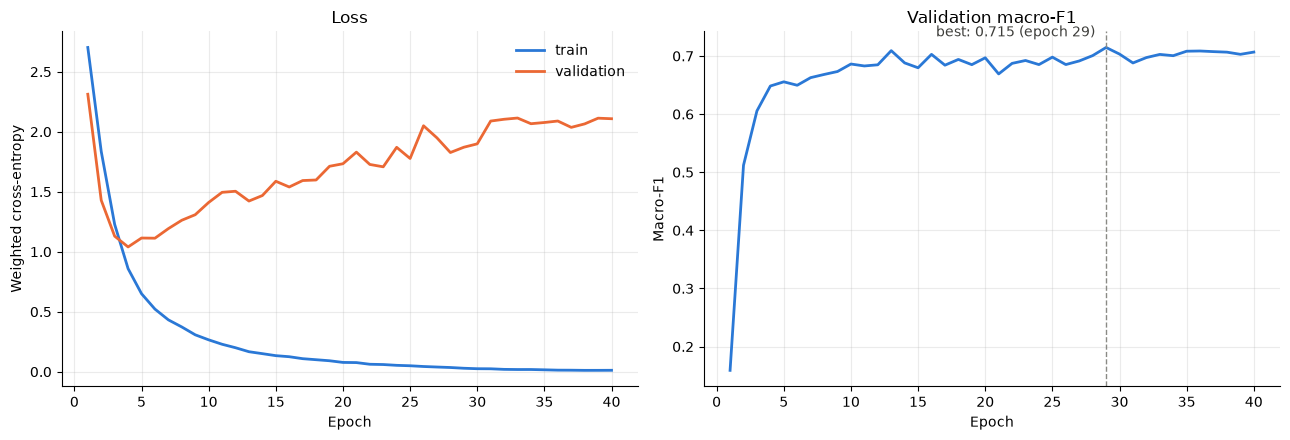

In [16]:
epochs = np.arange(1, num_epochs + 1)
train_color, val_color = "#2a78d6", "#eb6834"

fig, (ax_loss, ax_f1) = plt.subplots(1, 2, figsize=(13, 4.5))

ax_loss.plot(epochs, history["train_loss"], color=train_color, lw=2, label="train")
ax_loss.plot(epochs, history["val_loss"], color=val_color, lw=2, label="validation")
ax_loss.set(xlabel="Epoch", ylabel="Weighted cross-entropy", title="Loss")
ax_loss.legend(frameon=False)

ax_f1.plot(epochs, history["val_f1"], color=train_color, lw=2)
ax_f1.axvline(best_epoch, color="#8a8a85", lw=1, ls="--")
ax_f1.annotate(
    f"best: {best_f1:.3f} (epoch {best_epoch})",
    (best_epoch, best_f1),
    xytext=(-8, 8),
    textcoords="offset points",
    ha="right",
    color="#3d3d3a",
)
ax_f1.set(xlabel="Epoch", ylabel="Macro-F1", title="Validation macro-F1")

for ax in (ax_loss, ax_f1):
    ax.grid(alpha=0.25)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

Load the best model, print the scores for each activity, and draw the confusion matrix.

best epoch 29: validation macro-F1 = 0.7147

              precision    recall  f1-score   support

     walking      0.947     0.829     0.884       737
     jogging      0.992     0.984     0.988       737
      stairs      0.727     0.897     0.803       670
     sitting      0.560     0.496     0.526       738
    standing      0.609     0.828     0.702       670
      typing      0.870     0.711     0.783       737
       teeth      0.908     0.632     0.746       737
        soup      0.626     0.659     0.642       737
       chips      0.351     0.533     0.423       670
       pasta      0.554     0.558     0.556       737
    drinking      0.677     0.423     0.521       737
    sandwich      0.328     0.387     0.355       737
     kicking      0.909     0.858     0.883       737
       catch      0.969     0.803     0.878       737
   dribbling      0.995     0.764     0.864       737
     writing      0.681     0.704     0.692       737
    clapping      0.843     0.836   

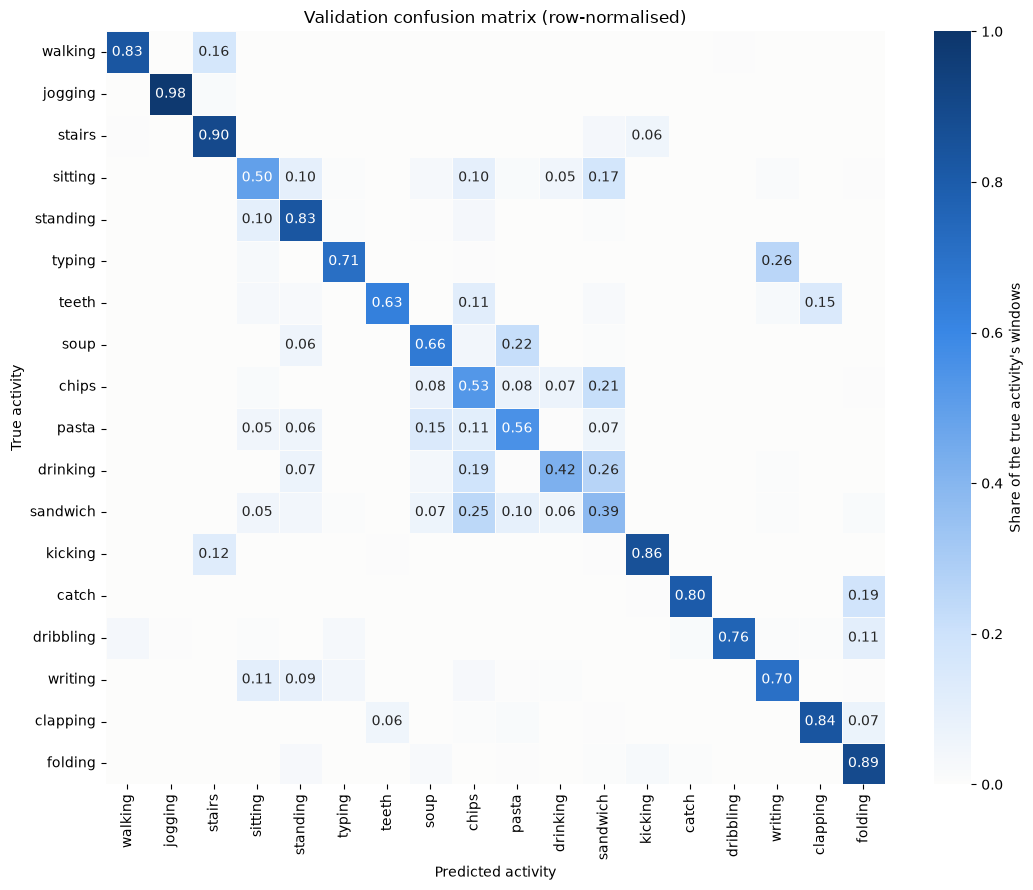

In [17]:
model.load_state_dict(best_state)
_, y_true, y_pred = evaluate(model, val_loader)

print(
    f"best epoch {best_epoch}: validation macro-F1 = {f1_score(y_true, y_pred, average='macro'):.4f}\n"
)
print(
    classification_report(
        y_true,
        y_pred,
        labels=range(num_classes),
        target_names=class_names,
        digits=3,
        zero_division=0,
    )
)

cm = confusion_matrix(y_true, y_pred, labels=range(num_classes), normalize="true")
labels = np.where(cm >= 0.05, np.char.mod("%.2f", cm), "")  # label only cells >= 5%
blues = LinearSegmentedColormap.from_list(
    "blues", ["#fcfcfb", "#cde2fb", "#86b6ef", "#3987e5", "#1c5cab", "#0d366b"]
)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap=blues,
    vmin=0,
    vmax=1,
    linewidths=0.5,
    linecolor="#fcfcfb",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Share of the true activity's windows"},
    ax=ax,
)
ax.set(
    xlabel="Predicted activity",
    ylabel="True activity",
    title="Validation confusion matrix (row-normalised)",
)
plt.tight_layout()
plt.show()